# Data Analysis Mathematics, Algorithms and Modeling

## Team Information - **Group Presentation 4**

**Team Members**

Name: Ayush Patel  
Student Number: 9033358

Name: Nikhil Shankar  
Student Number: 9026254

Name: Sreehari Prathap  
Student Number: 8903199


### **Prerequisites**
- Install Anaconda (for Jupyter Notebook) and Visual Studio Code (VS Code).
  - Anaconda: Visit [anaconda.com](https://www.anaconda.com/products/individual) and download the appropriate installer for your operating system.
  - VS Code: Download and install from [Visual Studio Code](https://code.visualstudio.com/).
- Install Pandas Library
  - Open the terminal and run the following command: `pip install pandas`

### **STEP : 1** - Collection and Preparation of Data
We are using the Salary data dataset from [Kaggle], which can be downloaded directly via the link:
- URL: [https://www.kaggle.com/datasets/mohithsairamreddy/salary-data]

A The dataset was obtained from multiple sources, including surveys, job posting sites, and other publicly available sources. A total of 6704 data points were collected.

The dataset included five variables: age, experience, job role, and education level and salary

### **STEP : 2** - Code Encapsulation into Classes and Methods

In [17]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')

# Class to handle employee data loading and preprocessing
class IterationHelper:
    def __init__(self, file_path, feature_list):
        employee_data = EmployeeData(file_path,
                             feature_list)
        employee_data.load_data()
        features = employee_data.preprocess_data()
        features = features.dropna()
        employee_data.gender_summary_statistics()
        # Step 2: Perform clustering
        clustering = EmployeeClustering(features)
        clustering.scale_features()
        clustering.find_optimal_k()
        clustered_data = clustering.apply_kmeans()
        # Step 3: Visualize the clusters
        for i,x in enumerate(employee_data.feature_list):
            for j in range(i+1, len(employee_data.feature_list)):
                if(x != employee_data.feature_list[j]):
                    clustering.visualize_clusters(x, employee_data.feature_list[j])
        return features
    
class EmployeeData:
    def __init__(self, file_path, feature_list):
        self.file_path = file_path
        self.data = None
        self.feature_list = feature_list


    def load_data(self):
        self.data = pd.read_csv(self.file_path)
        self.data = self.data.dropna()
        return self.data

    def preprocess_data(self):
        # Convert categorical data to numerical (if needed)
        self.data['Gender'] = self.data['Gender'].map({'Male': 0, 'Female': 1})
        # Select features for clustering
        self.features = self.data[self.feature_list]
        return self.features

    def gender_summary_statistics(self):
        # Display summary statistics by gender for key metrics
        summary_stats = self.data.groupby('Gender').agg('mean', 'median')
        print("Summary Statistics by Gender:\n", summary_stats)
        
        # # Visualizations to check distributions by gender
        # plt.figure(figsize=(10, 6))
        # sns.boxplot(x='Gender', y='Monthly_Salary', data=self.data)
        # plt.title("Monthly Salary Distribution by Gender")
        # plt.show()

        # plt.figure(figsize=(10, 6))
        # sns.boxplot(x='Gender', y='Performance_Score', data=self.data)
        # plt.title("Performance Score Distribution by Gender")
        # plt.show()

class Plotters:
    def plot_scatter(df, x, y, title, x_label, y_label):
        # Plot a scatter plot to visualize the relationship between two variables
        plt.figure(figsize=(10, 6))
        plt.scatter(df[x], df[y])
        plt.title(title)
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        # Calculate and display summary statistics
        x_mean = df[x].mean()
        y_mean = df[y].mean()
        correlation = df[[x, y]].corr().iloc[0, 1]
        summary_text = (
            f"Summary:\n"
            f"Mean of {x}: {x_mean:.2f}\n"
            f"Mean of {y}: {y_mean:.2f}\n"
            f"Correlation between {x} and {y}: {correlation:.2f}"
        )
        plt.figtext(0.15, -0.1, summary_text, wrap=True, fontsize=12, ha='left')
        plt.show()
        
    def plot_scatter_diagram(df, dependent_column_name):
        fig, axes = plt.subplots(4, int((len(df.columns)/4) + 1),figsize=(15,15))
        for i, col_name in enumerate(df.columns):
            if col_name != dependent_column_name:
                sns.scatterplot(x=col_name, y=dependent_column_name, data=df, ax=axes[i%4, i//4])
        plt.tight_layout()
        plt.show()

# Class to handle clustering operations
class EmployeeClustering:
    def __init__(self, data):
        self.data = data
        self.scaled_data = None
        self.model = None
        self.optimal_k = None

    def scale_features(self):
        scaler = StandardScaler()
        self.scaled_data = scaler.fit_transform(self.data)
        return self.scaled_data

    def find_optimal_k(self, max_k=10):
        sse = []
        for k in range(1, max_k + 1):
            kmeans = KMeans(n_clusters=k, random_state=42)
            kmeans.fit(self.scaled_data)
            sse.append(kmeans.inertia_)
        
        plt.plot(range(1, max_k + 1), sse)
        plt.xlabel("Number of Clusters (K)")
        plt.ylabel("SSE")
        plt.title("Elbow Method to Find Optimal K")
        plt.show()
        
        # After identifying optimal K from the plot, assign it
        self.optimal_k = int(input("Enter the optimal number of clusters (K) from the Elbow plot: "))

    def apply_kmeans(self):
        self.model = KMeans(n_clusters=self.optimal_k, random_state=42)
        self.data['Cluster'] = self.model.fit_predict(self.scaled_data)
        return self.data

    def visualize_clusters(self, x, y):
        plt.figure(figsize=(4, 4))
        sns.scatterplot(
            x=self.data[x], 
            y=self.data[y], 
            hue=self.data['Cluster'], 
            palette='viridis'
        )
        plt.title(f"Employee Clusters in {x} and {y}")
        plt.show()

# Class to handle bias analysis
class BiasAnalysis:
    def __init__(self, data):
        self.data = data

    def perform_statistical_tests(self):
        # Test for bias in Monthly Salary by Gender
        male_salary = self.data[self.data['Gender'] == 0]['Monthly_Salary']
        female_salary = self.data[self.data['Gender'] == 1]['Monthly_Salary']
        t_stat, p_val = ttest_ind(male_salary, female_salary)
        print("Monthly Salary T-test between Genders: T-statistic =", t_stat, ", P-value =", p_val)

        # Test for bias in Performance Score by Gender
        male_performance = self.data[self.data['Gender'] == 0]['Performance_Score']
        female_performance = self.data[self.data['Gender'] == 1]['Performance_Score']
        t_stat, p_val = ttest_ind(male_performance, female_performance)
        print("Performance Score T-test between Genders: T-statistic =", t_stat, ", P-value =", p_val)




#### EDA

In [18]:
# Load and clean data
employee_data = EmployeeData('../data/Salary_Data.csv',
                             ['Age', 'Years of Experience', 'Salary'])
data = employee_data.load_data()
features = employee_data.preprocess_data()
employee_data.gender_summary_statistics()
display(employee_data.data)
display(len(employee_data.data))

Summary Statistics by Gender:
               Age  Years of Experience         Salary
Gender                                               
0.0     34.418415             8.617407  121395.697630
1.0     32.626286             7.420179  107888.998672


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,0.0,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,1.0,Master's,Data Analyst,3.0,65000.0
2,45.0,0.0,PhD,Senior Manager,15.0,150000.0
3,36.0,1.0,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,0.0,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,1.0,PhD,Director of Marketing,20.0,200000.0
6700,32.0,0.0,High School,Sales Associate,3.0,50000.0
6701,30.0,1.0,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,0.0,Master's Degree,Marketing Manager,14.0,140000.0


6698

### **STEP : 3** - Summary of use case

We identified features Age, Years of Experience and Salary from the dataset and through this exploratory analysis we want to find clusters existing in the dataset using k-means. Once we identify the clusters we would like to identify presence of any bias that exists in the identified clusters based on gender.

### **STEP : 4** - Clustering Summary
Clustering allows us to group employees based on age, years of experience and salary to identify patterns and trends within the dataset. In our case we are using k-means for clustering.

### **STEP : 5** - Apply K-Means Clustering

> #### Select Features for Clustering: Choose relevant columns like Age, Years_At_Company, Salary.

#### Finding the ideal number of clusters.

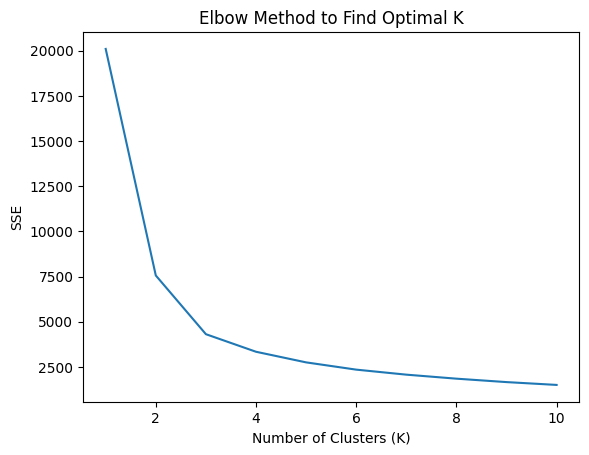

In [19]:
# Step 2: Perform clustering
clustering = EmployeeClustering(features)
clustering.scale_features()
clustering.find_optimal_k()
clustered_data = clustering.apply_kmeans()



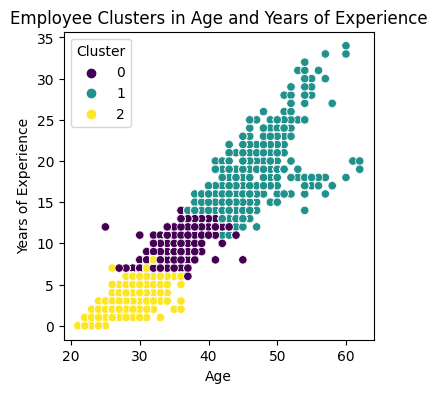

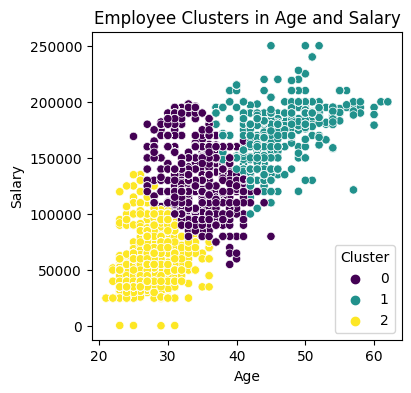

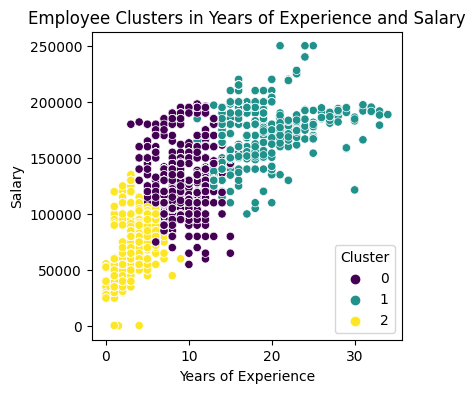

In [20]:
# Step 3: Visualize the clusters
for i,x in enumerate(employee_data.feature_list):
    for j in range(i+1, len(employee_data.feature_list)):
        if(x != employee_data.feature_list[j]):
            clustering.visualize_clusters(x, employee_data.feature_list[j])



#### **Analysing the Gender based disribution in the detected clusters**

In [21]:

clustered_data['Gender'] = employee_data.data[['Gender']]
gender_distribution = clustered_data.groupby('Cluster')['Gender'].value_counts().unstack(fill_value=0)
print("Gender 0 : Male and 1: Female")
print(gender_distribution)

Gender 0 : Male and 1: Female
Gender    0.0   1.0
Cluster            
0        1256  1175
1         956   471
2        1459  1367


#### **Findings**

- From the dataset we identified the numerical columns. Age, YearsOfExperience and Salary were selected and using elbow we found out that an optimal cluster value will be 3.
- From the plot we understood that the clusters is meaningful. It has succesfully clustered employees into 3 sections in all 3 combinations of the scatter plot. There were no overlaps in any of the scatter plots.
- We then checked the split of data in these 3 clusters based on gender. And we found the following
    -- The high salary drawing cluster ie the 1st Cluster ( Green ) has a bias towards tge male employees. The ratio in other two clusters are evenly distributed. 
    -- The first cluster is draws more than 100000 salary, has more than 12 years experience and has age above 37. And there is a significant bias that we can notice in this group which is in favour of Male employees.